## Phase 1 : Dataset Exploration

### Step 1: Import Required Libraries

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42



### Step 2: Load Dataset

In [56]:
dataset_path = Path(
    "../datasets/fertilizer_recommendation/fertilizer_recommendation.csv"
)

print("Dataset Exists :", dataset_path.exists())

fertilizer_df = pd.read_csv(dataset_path)

print("\nDataset Loaded Successfully")

print("Dataset Shape :", fertilizer_df.shape)


Dataset Exists : True

Dataset Loaded Successfully
Dataset Shape : (3100, 12)


### Step 3: Dataset Overview

In [57]:
fertilizer_df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [58]:
fertilizer_df.shape

(3100, 12)

In [59]:
fertilizer_df.columns.tolist()

['Temperature',
 'Moisture',
 'Rainfall',
 'PH',
 'Nitrogen',
 'Phosphorous',
 'Potassium',
 'Carbon',
 'Soil',
 'Crop',
 'Fertilizer',
 'Remark']

In [60]:
fertilizer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


### Step 4: Check Missing & Duplicate Values

In [61]:
print("Missing Values\n")

print(fertilizer_df.isnull().sum())



Missing Values

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64


In [62]:
print("\nDuplicate Records :", fertilizer_df.duplicated().sum())


Duplicate Records : 0


### Step 5: Dataset Columns & Target

In [63]:
target_column = "Fertilizer"

print("Target Column :", target_column)

print()

print("Number of Fertilizer Classes :")

print(fertilizer_df[target_column].nunique())

print()

print("Classes:\n")

print(sorted(fertilizer_df[target_column].unique()))

Target Column : Fertilizer

Number of Fertilizer Classes :
10

Classes:

['Balanced NPK Fertilizer', 'Compost', 'DAP', 'General Purpose Fertilizer', 'Gypsum', 'Lime', 'Muriate of Potash', 'Organic Fertilizer', 'Urea', 'Water Retaining Fertilizer']


### Step 6: Statistical Summary

In [64]:
fertilizer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,3100.0,27.271096,9.114450,4.011486,22.408505,26.132938,29.987887,56.653592
Moisture,3100.0,0.600763,0.144947,0.227436,0.493595,0.599520,0.708575,0.972361
Rainfall,3100.0,111.024949,77.151880,-85.709593,61.283985,96.485935,147.619401,411.955947
PH,3100.0,6.379775,0.957103,3.448974,5.860489,6.337308,6.899739,9.562341
Nitrogen,3100.0,61.278480,10.186410,35.527718,54.835715,59.429649,65.792790,98.581039
Phosphorous,3100.0,69.582850,42.226712,-37.649739,43.039260,58.205269,86.108983,177.314481
Potassium,3100.0,69.721167,35.304241,-20.509108,49.992405,58.710808,76.318626,161.067982
Carbon,3100.0,1.474325,0.698300,-0.280560,0.956401,1.463357,2.003534,3.241984


### Step 7: Outlier Analysis

In [65]:
numerical_columns = fertilizer_df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Features:\n")

print(list(numerical_columns))

Numerical Features:

['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']


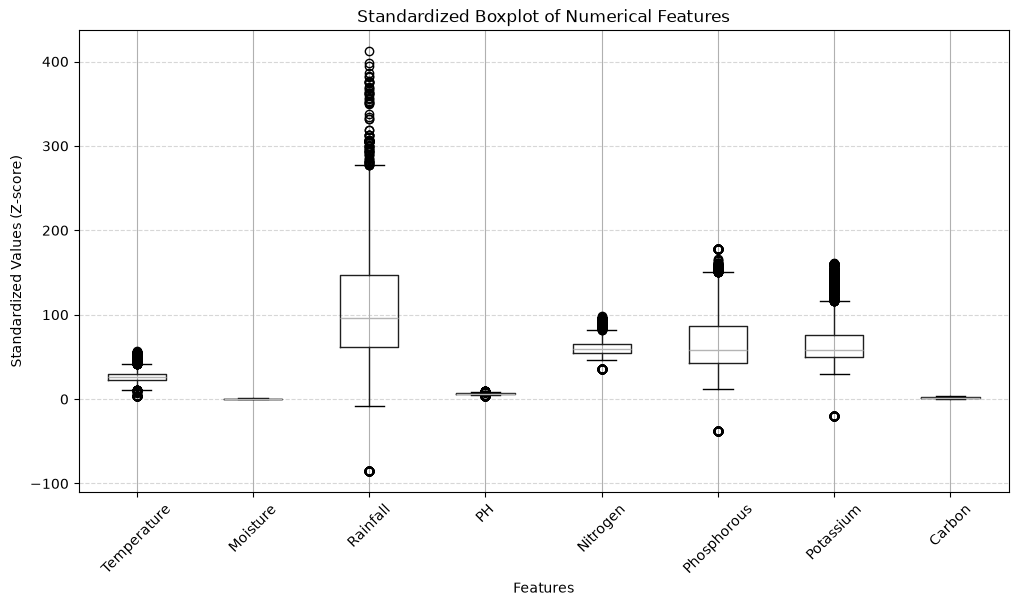

In [66]:
plt.figure(figsize=(12, 6))
fertilizer_df.boxplot()

plt.title("Standardized Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Standardized Values (Z-score)")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Phase 2: Data Preparation

### Step 8: Separate Features & Target

In [67]:
X = fertilizer_df.drop(columns=["Fertilizer", "Remark"])

y = fertilizer_df["Fertilizer"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nInput Features:\n")
print(X.columns.tolist())

Feature Shape : (3100, 10)
Target Shape  : (3100,)

Input Features:

['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop']


### Step 9: Encode Categorical Features

In [68]:
categorical_columns = [
    "Soil",
    "Crop"
]

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

print("Categorical Encoding Completed Successfully")
print("Encoded Feature Shape :", X.shape)

Categorical Encoding Completed Successfully
Encoded Feature Shape : (3100, 44)


In [69]:
print("Encoded Features:\n")

print(X.columns.tolist())

Encoded Features:

['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil_Acidic Soil', 'Soil_Alkaline Soil', 'Soil_Loamy Soil', 'Soil_Neutral Soil', 'Soil_Peaty Soil', 'Crop_Adzuki Beans', 'Crop_Black gram', 'Crop_Chickpea', 'Crop_Coconut', 'Crop_Coffee', 'Crop_Cotton', 'Crop_Ground Nut', 'Crop_Jute', 'Crop_Kidney Beans', 'Crop_Lentil', 'Crop_Moth Beans', 'Crop_Mung Bean', 'Crop_Peas', 'Crop_Pigeon Peas', 'Crop_Rubber', 'Crop_Sugarcane', 'Crop_Tea', 'Crop_Tobacco', 'Crop_apple', 'Crop_banana', 'Crop_grapes', 'Crop_maize', 'Crop_mango', 'Crop_millet', 'Crop_muskmelon', 'Crop_orange', 'Crop_papaya', 'Crop_pomegranate', 'Crop_rice', 'Crop_watermelon', 'Crop_wheat']


### Step 10: Encoding

In [70]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label Encoding Completed Successfully")

print("\nFertilizer Classes:\n")

print(label_encoder.classes_)

Label Encoding Completed Successfully

Fertilizer Classes:

['Balanced NPK Fertilizer' 'Compost' 'DAP' 'General Purpose Fertilizer'
 'Gypsum' 'Lime' 'Muriate of Potash' 'Organic Fertilizer' 'Urea'
 'Water Retaining Fertilizer']


### Step 11: Train-Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y_encoded

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])

print("\nTraining Feature Shape :", X_train.shape)

print("Testing Feature Shape  :", X_test.shape)

Training Samples : 2480
Testing Samples  : 620

Training Feature Shape : (2480, 44)
Testing Feature Shape  : (620, 44)


### Step 12: Feature Scaling

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

print("\nScaled Training Shape :", X_train_scaled.shape)

print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully

Scaled Training Shape : (2480, 44)
Scaled Testing Shape  : (620, 44)


## Phase 3: Model Selection

### Step 13: Train Baseline Models

In [73]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        random_state=RANDOM_STATE
    )

}

results = {}

print("Training Models...\n")

for name, model in models.items(): 
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"{name:<22} Accuracy : {accuracy:.4f}")

Training Models...

Logistic Regression    Accuracy : 0.8000
Decision Tree          Accuracy : 0.9919
KNN                    Accuracy : 0.5532
Random Forest          Accuracy : 0.9806
SVM                    Accuracy : 0.6581


### Step 14: Compare Model Performance

In [74]:
results_df = pd.DataFrame(

    results.items(),

    columns=["Model", "Accuracy"]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

results_df

,Model,Accuracy
0,Decision Tree,0.991935
1,Random Forest,0.980645
2,Logistic Regression,0.800000
3,SVM,0.658065
4,KNN,0.553226


### Accuracy Comparison Graph

C:\Users\HP\AppData\Local\Temp\ipykernel_18696\3649604350.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


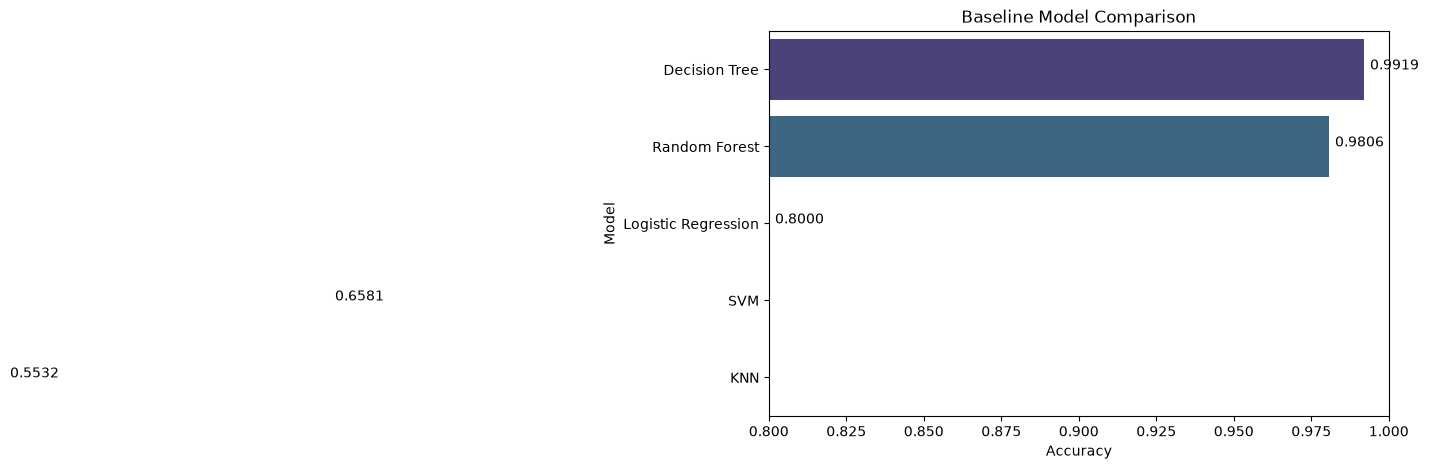

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model",

    hue="Model",

    palette="viridis",

    legend=False

)

plt.title("Baseline Model Comparison")

plt.xlim(0.80, 1.00)

for index, value in enumerate(results_df["Accuracy"]):

    plt.text(value + 0.002, index, f"{value:.4f}")

plt.tight_layout()

plt.show()

### Step 15: Cross Validation

In [76]:
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    decision_tree,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:\n")
print(cv_scores)

print("\nAverage CV Accuracy : {:.4f}".format(cv_scores.mean()))

Cross Validation Scores:

[0.99354839 0.99677419 0.99677419 0.99677419 0.99032258]

Average CV Accuracy : 0.9948


### Step 16: Hyperparameter Tuning

In [77]:
param_grid = {

    "criterion": ["gini", "entropy"],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

grid_search = GridSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

print("\nHyperparameter Tuning Completed Successfully")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Hyperparameter Tuning Completed Successfully


In [78]:
print("Best Parameters:\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy :")

print(f"{grid_search.best_score_:.4f}")

Best Parameters:

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy :
0.9923


## Phase 4: Model Evaluation

### Step 17: Train Final Optimized Model

In [79]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

print("Final Optimized Decision Tree Model Trained Successfully")

Final Optimized Decision Tree Model Trained Successfully


### Step 18: Evaluate Final Model

In [80]:
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")

Test Accuracy : 99.19%


### Step 19: Confusion Matrix

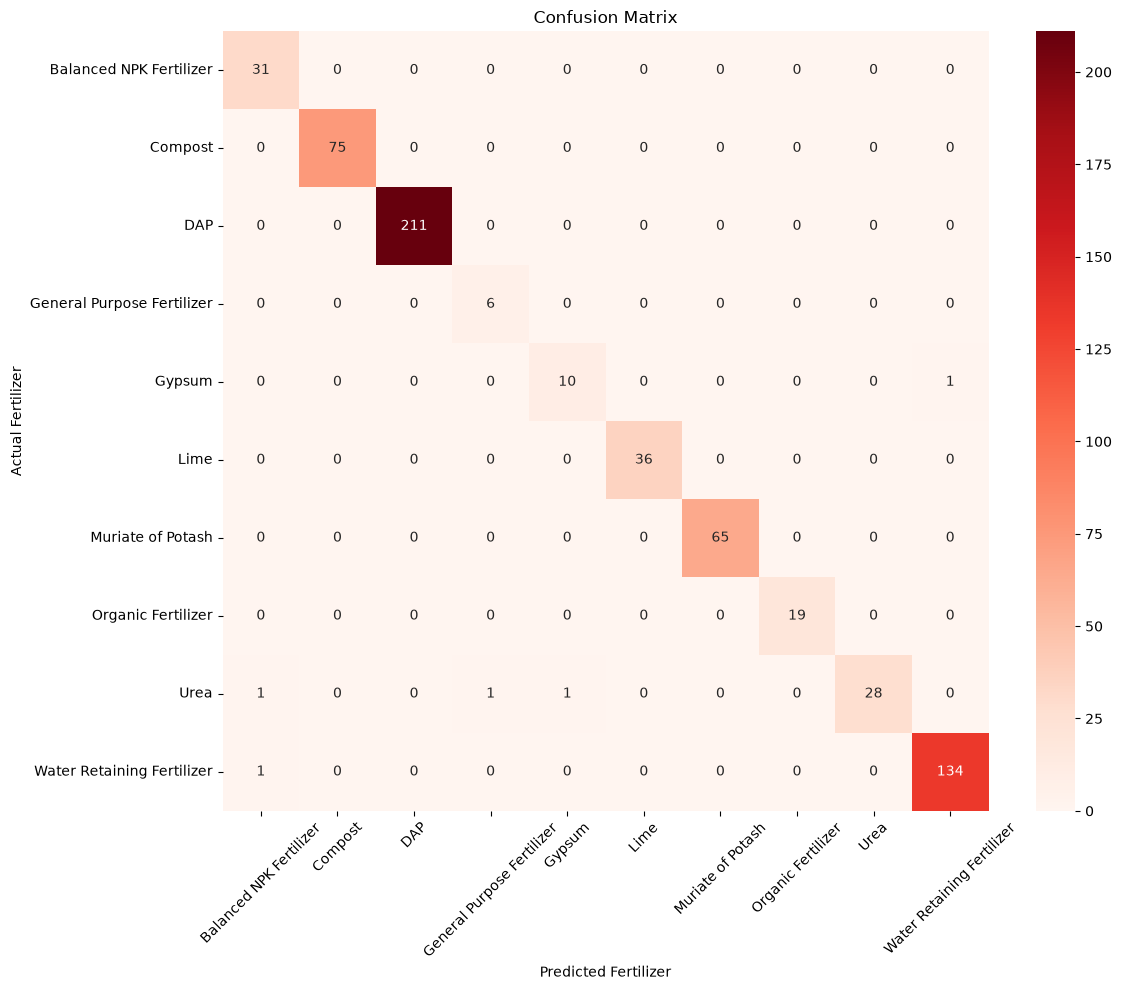

In [81]:
plt.figure(figsize=(12,10))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Step 20: Classification Report

In [82]:
report = classification_report(

    y_test,

    y_pred,

    target_names=label_encoder.classes_,

    digits=4

)

print(report)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer     0.9394    1.0000    0.9688        31
                   Compost     1.0000    1.0000    1.0000        75
                       DAP     1.0000    1.0000    1.0000       211
General Purpose Fertilizer     0.8571    1.0000    0.9231         6
                    Gypsum     0.9091    0.9091    0.9091        11
                      Lime     1.0000    1.0000    1.0000        36
         Muriate of Potash     1.0000    1.0000    1.0000        65
        Organic Fertilizer     1.0000    1.0000    1.0000        19
                      Urea     1.0000    0.9032    0.9492        31
Water Retaining Fertilizer     0.9926    0.9926    0.9926       135

                  accuracy                         0.9919       620
                 macro avg     0.9698    0.9805    0.9743       620
              weighted avg     0.9924    0.9919    0.9919       620



### Step 21: Feature Importance

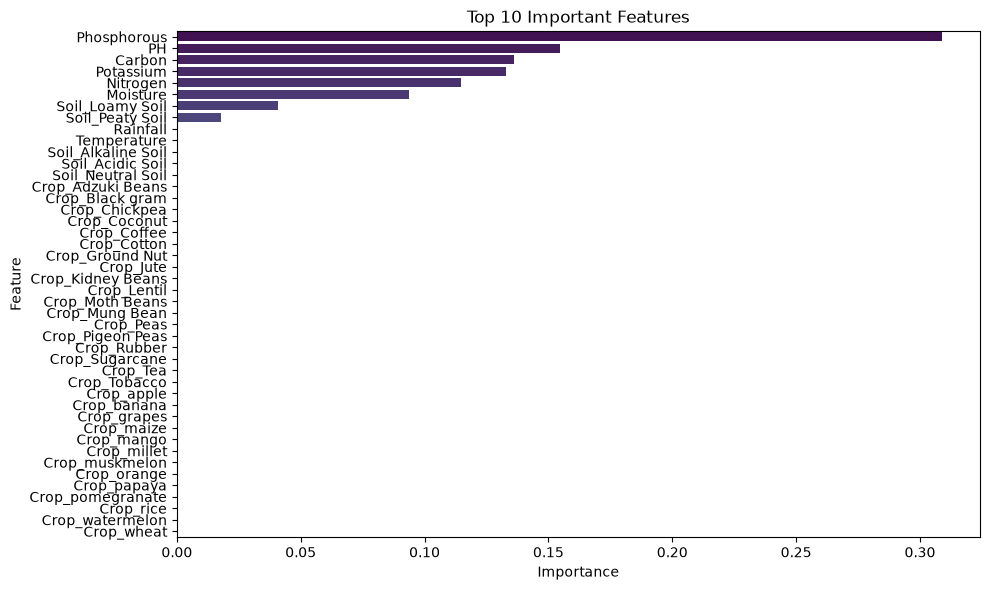

,Feature,Importance
5,Phosphorous,0.308786
3,PH,0.154566
7,Carbon,0.136243
6,Potassium,0.133010
4,Nitrogen,0.114569
1,Moisture,0.093675
10,Soil_Loamy Soil,0.040939
12,Soil_Peaty Soil,0.017709
2,Rainfall,0.000503
0,Temperature,0.000000


In [83]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature",

    hue="Feature",

    palette="viridis",

    legend=False

)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()

feature_importance


## Phase 5: Model Saving & Deployment Preparation

### Step 22: Save Decision Tree Model

In [84]:
model_directory = Path("../models")

model_directory.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    model_directory / "fertilizer_recommendation_model.pkl"
)

print("Decision Tree Model Saved Successfully")

Decision Tree Model Saved Successfully


In [85]:
joblib.dump(
    X.columns.tolist(),
    model_directory / "fertilizer_feature_names.pkl"
)

print("Feature Names Saved Successfully")

Feature Names Saved Successfully


### Step 23: Save Preprocessing Objects

In [86]:
joblib.dump(
    scaler,
    model_directory / "fertilizer_scaler.pkl"
)

joblib.dump(
    label_encoder,
    model_directory / "fertilizer_label_encoder.pkl"
)

print("Preprocessing Objects Saved Successfully")

Preprocessing Objects Saved Successfully


### Step 24: Save Fertilizer → Remark Mapping

In [87]:
remark_lookup = (
    fertilizer_df[["Fertilizer", "Remark"]]
    .drop_duplicates()
    .set_index("Fertilizer")["Remark"]
    .to_dict()
)

joblib.dump(
    remark_lookup,
    model_directory / "fertilizer_remark_lookup.pkl"
)

print("Remark Lookup Saved Successfully")

Remark Lookup Saved Successfully


### Step 25: Prediction Function

In [88]:
def recommend_fertilizer(
    input_data
):
    prediction = best_model.predict(input_data)

    fertilizer = label_encoder.inverse_transform(prediction)[0]

    remark = remark_lookup[fertilizer]

    return fertilizer, remark

### Step 26: Test Prediction

In [89]:
sample = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)

sample["Temperature"] = 28
sample["Moisture"] = 45
sample["Rainfall"] = 120
sample["PH"] = 6.5
sample["Nitrogen"] = 80
sample["Phosphorous"] = 45
sample["Potassium"] = 40
sample["Carbon"] = 8

sample["Soil_Loamy Soil"] = 1
sample["Crop_rice"] = 1

fertilizer, remark = recommend_fertilizer(sample)

print("Recommended Fertilizer :", fertilizer)
print("\nRemark :")
print(remark)

Recommended Fertilizer : DAP

Remark :
Rich in phosphorus, essential for root development. Prefer this for phosphorus-deficient soils to improve plant establishment.
